# CUSTOMER CHURN PREDICTION MODEL

## PROBLEM STATEMENT:
**The goal is to predict whether a customer will churn based on their demographics, account information, subscribed services, and billing details. This is a binary classification problem, where:**

**Input: Customer attributes (numerical + categorical features)**

**Output: Churn status (Yes or No)**

## KAGGLE DATASET

**https://www.kaggle.com/datasets/mustafaoz158/telco-customer-churn**

## DATASET OVERVIEW:
**The dataset contains detailed information about a telecom company’s customers, including:**

**Demographics:** Gender, SeniorCitizen, Partner, Dependents

**Account Information:** Tenure, Contract type, Payment method, Paperless billing

**Services Subscribed:** Phone service, Internet service, Online security, Online backup, Device protection, Tech support, Streaming TV, Streaming movies

**Charges:** Monthly charges, Total charges

**Target Variable:** Churn (Yes/No)

## LIBRARIES REQUIRED
* **pandas** - For data loading, cleaning and manipulation
* **Matplotlib** - For Plotting the charts
* **Seaborn** - For Data Visualization (EDA)
* **Scikit-Learn**  - For machine learning, deep learning, building model, preprocessing, and evaluation.
* **joblib** - For saving models, encoders and scaler

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,recall_score
import joblib

## LOADING DATA

In [10]:
data = pd.read_csv("Telco-Customer-Churn.csv")
df = pd.DataFrame(data)

## CLEANING DATA, HANDLING MISSING VALUES, CHECKING DATA TYPES:

In [11]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.info()
df.shape
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
# Displaying count of each category for categorical columns
for col in df.select_dtypes(include=[object]).columns:
    print(df[col].value_counts())
    print('--' * 20)

customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64
----------------------------------------
gender
Male      3555
Female    3488
Name: count, dtype: int64
----------------------------------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64
----------------------------------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
----------------------------------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
----------------------------------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
----------------------------------------
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
----------------------------------------
OnlineSecurity
No       

In [14]:
#df.drop(columns = ["customerID"], inplace = True)

# convert TotalCharges to numeric safely
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


C:\Users\bjc\AppData\Local\Temp\ipykernel_20176\1282520868.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


## EXPLORATORY DATA ANALYSIS 

In [15]:
df["Churn"].value_counts()
sns.set_style("whitegrid")

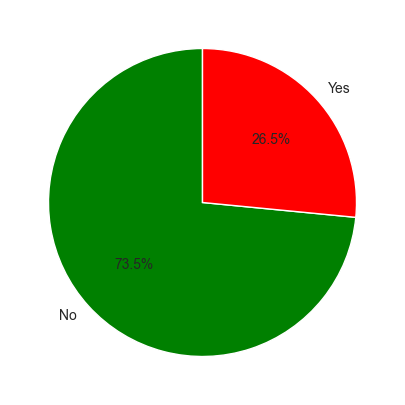

In [16]:
plt.figure(figsize= (6, 5))
plt.pie(x = df["Churn"].value_counts(), data = df, labels = ["No", "Yes"],  autopct="%1.1f%%", startangle=90,colors = ["green", "red"])
plt.show()

In [17]:
def bar_charts(column):
    plt.figure(figsize=(6,4))
    df.groupby(column)["Churn"].value_counts().unstack().plot(kind="bar", color = ["green", "red"])
    plt.title(f"Churn by {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.legend(["No Churn", "Churn"])
    plt.show()

<Figure size 600x400 with 0 Axes>

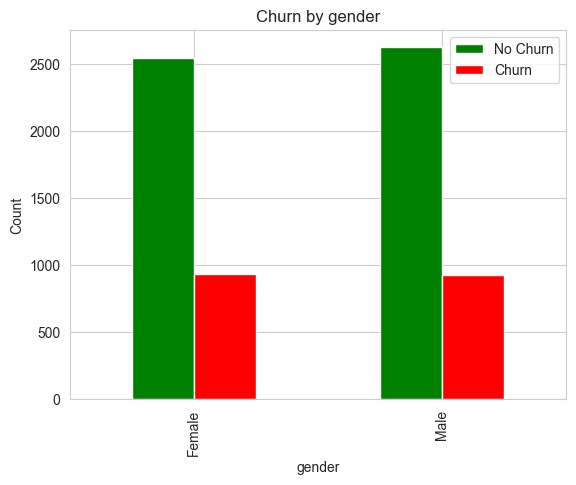

<Figure size 600x400 with 0 Axes>

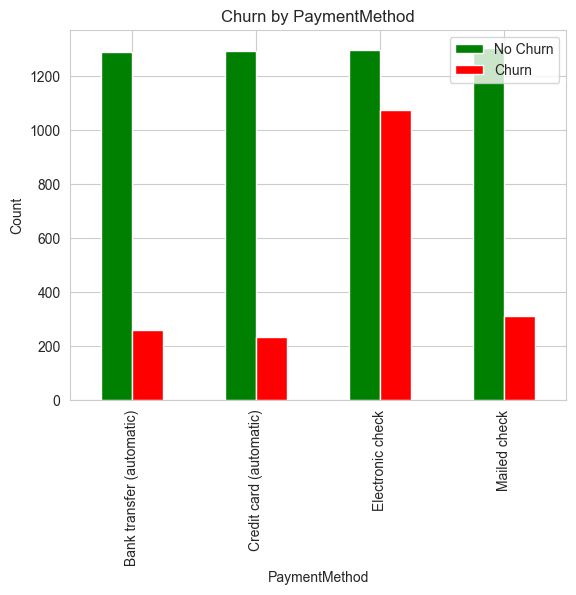

<Figure size 600x400 with 0 Axes>

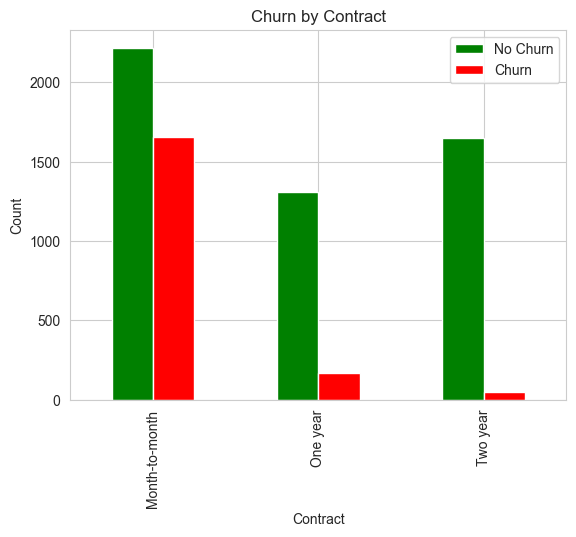

<Figure size 600x400 with 0 Axes>

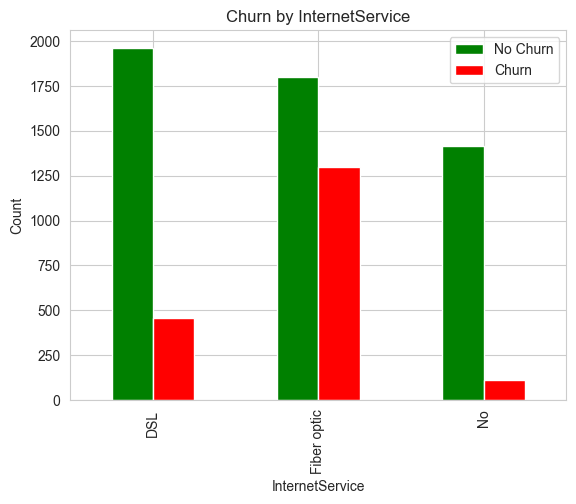

In [18]:
# Using bar charts for generating different columns by churn
bar_charts("gender")
bar_charts("PaymentMethod")
bar_charts("Contract")
bar_charts("InternetService")

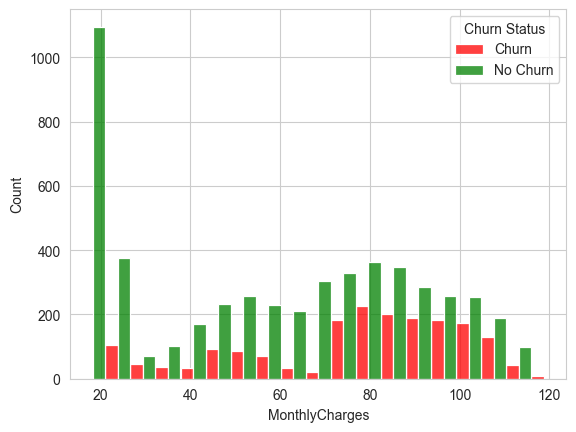

In [19]:
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", palette =  ["green", "red"], multiple = "dodge")
plt.legend(title="Churn Status", labels=["Churn", "No Churn"])

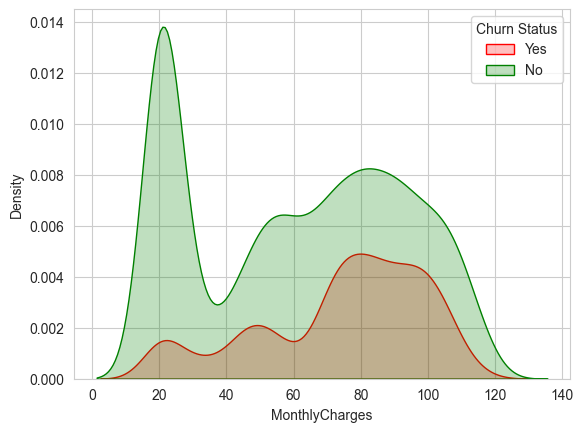

In [20]:
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill = True, palette = ["green", "red"])
plt.legend(title = "Churn Status", labels = ["Yes", "No"])

C:\Users\bjc\AppData\Local\Temp\ipykernel_20176\2604094859.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_services[col] = df_services[col].replace({"Yes":1, "No":0, "No phone service":0, "No internet service":0})


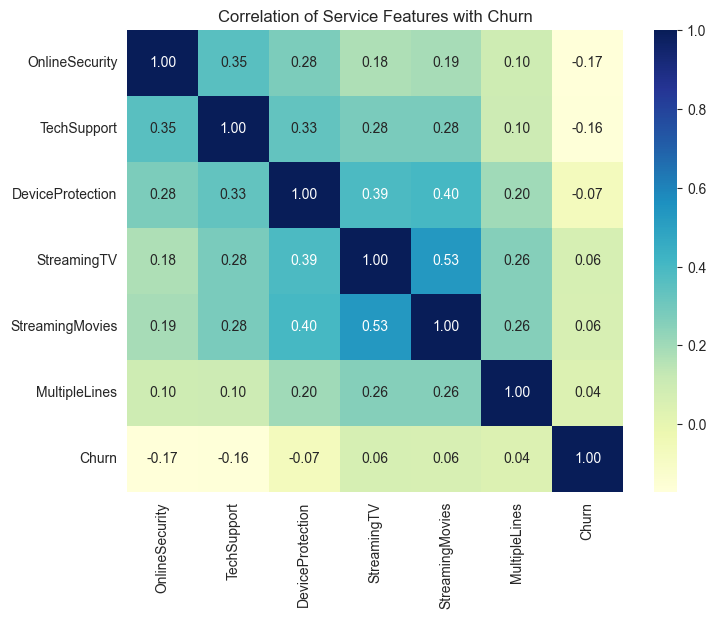

In [21]:
# List of service-related columns
service_cols = [
    "OnlineSecurity",
    "TechSupport",
    "DeviceProtection",
    "StreamingTV",
    "StreamingMovies",
    "MultipleLines",
    "Churn"   # target
]

# Make sure all are numeric (0/1)
df_services = df[service_cols].copy()
for col in df_services.columns:
    df_services[col] = df_services[col].replace({"Yes":1, "No":0, "No phone service":0, "No internet service":0})

# Compute correlation matrix
corr = df_services.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation of Service Features with Churn")
plt.show()


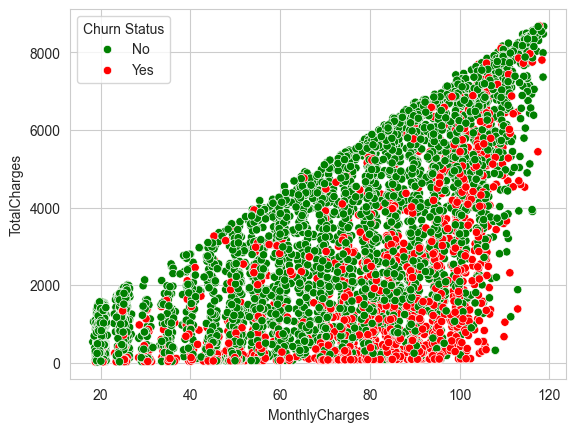

In [22]:
sns.scatterplot(x = df["MonthlyCharges"], y = df["TotalCharges"], hue = df["Churn"], palette = ["green", "red"])
plt.legend(title = "Churn Status")

**ENCODING CATEGORICAL DATA**

In [23]:
# Convert all categorical columns to One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

In [24]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,False,False,False,False,False,False,...,True,False,True,True,False,True,False,False,True,False
7039,0,72,103.20,7362.90,False,False,False,False,False,False,...,True,False,True,True,False,True,True,False,False,False
7040,0,11,29.60,346.45,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
7041,1,4,74.40,306.60,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True


**Training Datasets:**

In [25]:
x = df.drop(columns = ["Churn_Yes"])
y = df["Churn_Yes"]

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

**Scaling Data**

In [19]:
scaler = StandardScaler()

numeric_cols = ['tenure','MonthlyCharges','TotalCharges']

x_train[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])   # fit + transform
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])         # only transform because this is test data 


In [20]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(x.columns, "columns.pkl")

['columns.pkl']

### ML MODELS:

In [27]:
models = []
recall_scores = []

def predict(x_train, y_train, x_test, y_test, model, name):
    print("Model Used: ", name)
    model = model
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    print("Accuracy: ", accuracy_score(y_test, y_pred))
    print("CLASSIFICATION REPORT")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    # Plot
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d')
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    
    plt.show()
    models.append(name)
    recall = recall_score(y_test, y_pred)
    recall_scores.append(recall)

    joblib.dump(model, f"{name}.pkl")
    print(f"Saved model: {name}.pkl")

**LOGISTIC REGRESSION**

Model Used:  Logistic Regression
Accuracy:  0.8211497515968772
CLASSIFICATION REPORT
              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409

[[934 102]
 [150 223]]


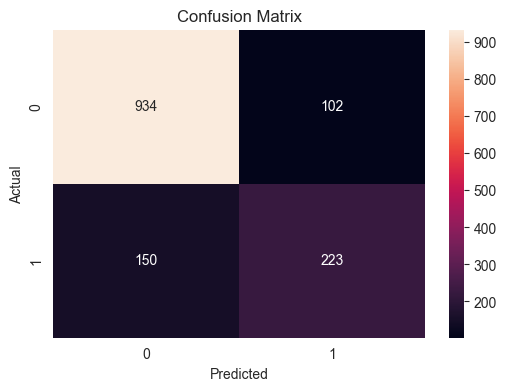

Saved model: Logistic Regression.pkl


In [22]:
predict(x_train, y_train, x_test, y_test, LogisticRegression(max_iter = 1000 ), "Logistic Regression")

**DECISION TREE CLASSIFIER**

Model Used:  Decision Tree
Accuracy:  0.7771469127040455
CLASSIFICATION REPORT
              precision    recall  f1-score   support

       False       0.83      0.88      0.85      1036
        True       0.59      0.50      0.54       373

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

[[909 127]
 [187 186]]


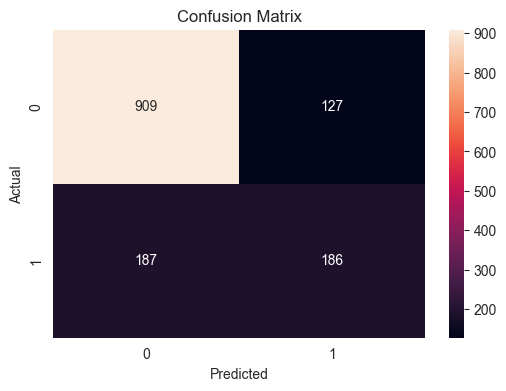

Saved model: Decision Tree.pkl


In [23]:
predict(x_train, y_train, x_test, y_test, DecisionTreeClassifier(), "Decision Tree")

**RANDOM FOREST CLASSIFIER**

Model Used:  Random Forest
Accuracy:  0.7352732434350603
CLASSIFICATION REPORT
              precision    recall  f1-score   support

       False       0.74      1.00      0.85      1036
        True       0.00      0.00      0.00       373

    accuracy                           0.74      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.74      0.62      1409

[[1036    0]
 [ 373    0]]


C:\Users\bjc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bjc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bjc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

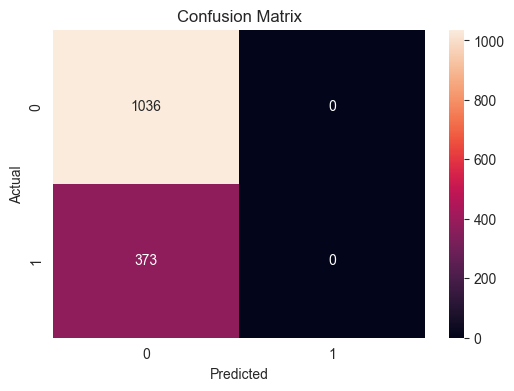

Saved model: Random Forest.pkl


In [28]:
predict(x_train, y_train, x_test, y_test, RandomForestClassifier(n_estimators=100, max_depth=10,
    random_state=42), "Random Forest")

**SUPPORT VECTOR MACHINE**

Model Used:  Support Vector Machine
Accuracy:  0.7977288857345636
CLASSIFICATION REPORT
              precision    recall  f1-score   support

       False       0.88      0.84      0.86      1036
        True       0.61      0.67      0.64       373

    accuracy                           0.80      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.80      0.80      0.80      1409

[[875 161]
 [124 249]]


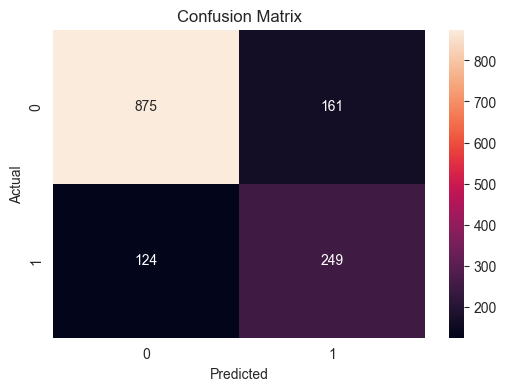

Saved model: Support Vector Machine.pkl


In [25]:
predict(x_train, y_train, x_test, y_test, SVC(kernel='linear', probability=False, class_weight='balanced' ), "Support Vector Machine")

**NEURAL NETWORK: MLP CLASSIFIER**

Model Used:  Neural Network
Accuracy:  0.8190205819730305
CLASSIFICATION REPORT
              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.68      0.59      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409

[[934 102]
 [153 220]]


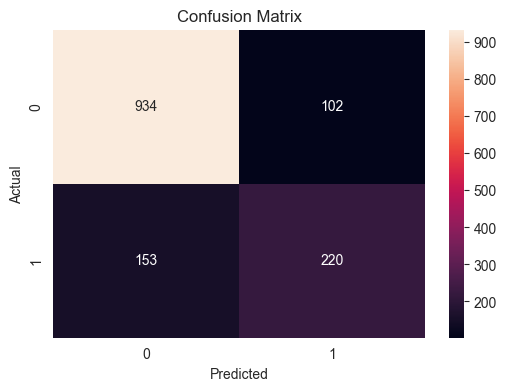

Saved model: Neural Network.pkl


In [26]:
predict(x_train, y_train, x_test, y_test, MLPClassifier(
        hidden_layer_sizes=(30,),   # small = fast
        activation="relu",
        max_iter=150,
        alpha=0.001,
        random_state=42), "Neural Network")

**MODEL COMAPRISON - RECALL**

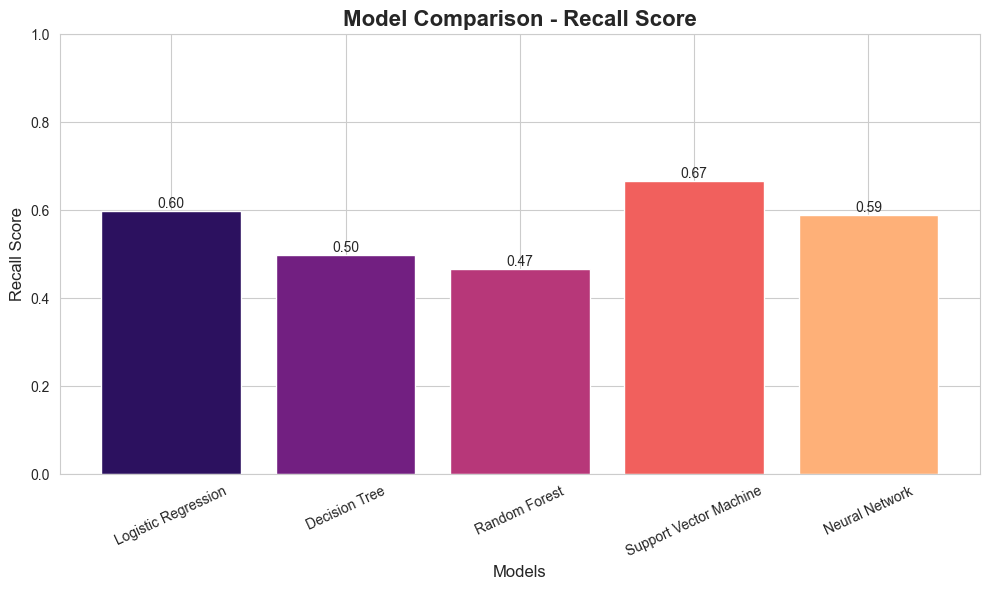

In [27]:
sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

bars = plt.bar(models, recall_scores, color=sns.color_palette("magma", len(models)))

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=10)

plt.title("Model Comparison - Recall Score", fontsize=16, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Recall Score", fontsize=12)
plt.ylim(0, 1)

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()